<a href="https://colab.research.google.com/github/ManJ-PC/Natural-Language-Processing/blob/main/ATTRACT_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

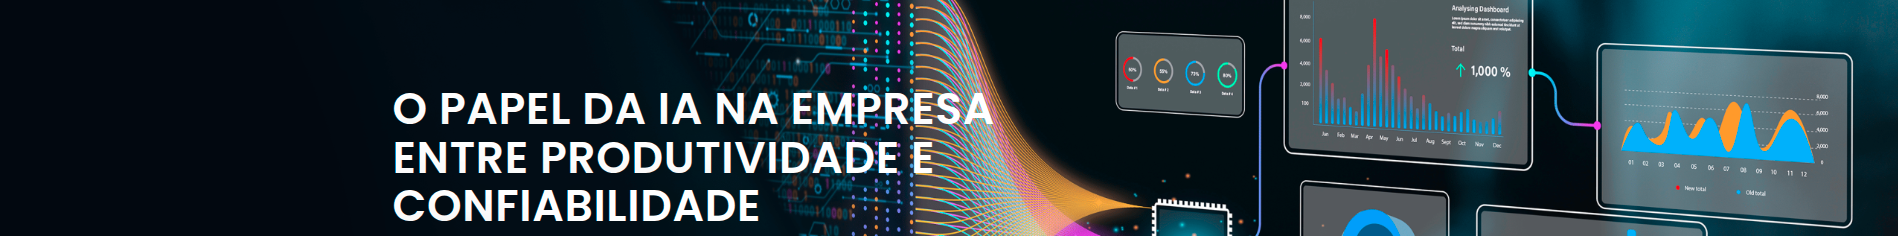

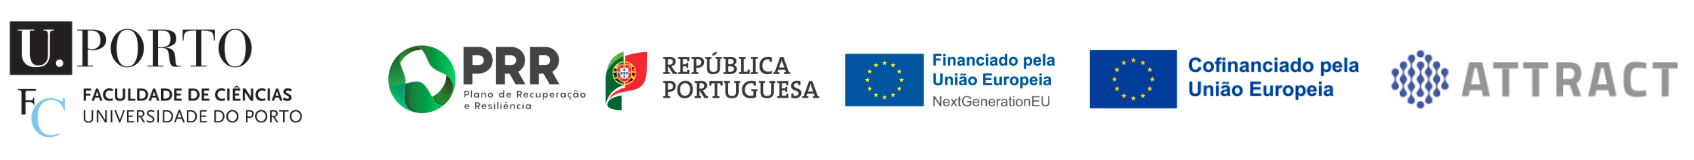

#FUNDAMENTOS DA IA GENERATIVA


##Guardar cópia local

Comece por copiar o Colab para a sua Drive pessoal.
Para isso, vá a **Ficheiro (File)** e seleccione **Guardar uma cópia no Drive (Save a copy in Drive)**.

Este processo irá criar uma cópia editável do notebook, que poderá modificar e executar livremente na sua conta durante e após a workshop.



## Linguagem Python

Nesta workshop vamos usar a linguagem de programação Python. O Python é uma linguagem de muito alto nível e é interpretada (não necessita dos passos de compilação). É grátis e de código aberto. Tem uma sintaxe simples e é de fácil aprendizagem, sendo muito portável (funciona em quase todas as arquitecturas e sistemas operativos). É também de tipagem dinâmica, ou seja, os tipos de variáveis são detectados dinamicamente, sem ser necessário explicitamente dizer o seu tipo.

## Google Colab

Para facilitar a execução dos exemplos de códiog Python, neste workshop vamos usar o Google Colab. Esta ferramenta permite a execução de código Python online.

Para isso o primeiro passo é fazer login na conta Google pessoal. Depois vá a **Ficheiro -> Guardar cópia no Drive** para fazer uma cópia para a sua drive pessoal e começar a realizar os exercícios

O Google Colab permite criar dois tipos de células: **texto** ou **código**

As células de texto permitem escrever texto e tem um editor que permite colocar títulos, imagens links, listas etc.

As células de código permitem escrever e executar código em linguagem Python. Para isso deve-se escrever o código a ser executado e clicar no icon play ao lado esquerdo da célula:

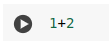




##Outras informações úteis sobre o Google Colab



- **Adicionar novas células:**  
  - Menu superior: `+ Texto` ou `+ Código`.  

- **Editar ou reordenar células:**  
  - Use a seta para cima ou para baixo no canto superior direito da célula para alterar a sua posição. Clique duas vezes na célula para a editar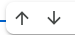

- **Carregar ficheiros:**  
  - Use o painel lateral “Ficheiros” para carregar ficheiros do seu computador.  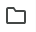
  - Pode montar a sua Google Drive (depois de clicar em Ficheiros) para aceder aos dados que lá estão guardados.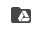

- **GPU e TPU gratuitas:**  
  - Para ativar: “Ambiente de execução” → “Alterar tipo de ambiente de execução” . Pode ser usado nos exercícios de RAG mas para já vamos poupar os créditos gratuitos a que temos acesso.

- **Instalar bibliotecas adicionais:**  
  - Use comandos como `!pip install nome_da_biblioteca` diretamente numa célula de código.

- **Limpar ou reiniciar ambiente de execução:**  
  - Menu “Ambiente de execução” → “Reiniciar sessão”.

#Explorar o modelo GPT2

Nesta parte da workshop vamos começar por experimentar usar o GPT2, um dos primeiros modelos GPT disponibilizados pela OpenAI

Primeiro vamos carregar as bibliotecas necessárias. Vamos usar o transformers, uma das bibliotecas mais conhecidas para utilizar modelos de linguagem

In [1]:
from transformers import pipeline, set_seed


Vamos utilizar os pipelines desta biblioteca, o que simplifica bastante o processo de carregamento e utilização dos modelos.

Na célula de código abaixo,temos a chamada a uma função *pipeline* da biblioteca onde o primeiro argumento 'text-generation' indica o tipo de tarefa de Processamento de Linguagem Natural (PLN) que queremos executar (neste caso, será a geração de texto).

Em seguida, no segundo argumento, definimos o modelo que pretendemos usar nessa tarefa (através do argumento model). Colocamos, portanto, "gpt-2" como o modelo a utilizar. Por fim, o argumento device=-1 indica que queremos utilizar o CPU em vez da GPU.

Embora esta opção torne o processo um pouco mais lento, permite executar os modelos no Google Colab sem necessidade de GPU. Como mencionado anteriormente, a Google oferece acesso limitado a GPUs para utilizadores sem conta Pro, mas vamos reservar esses recursos para utilizações futuras.

In [2]:
gpt2 = pipeline('text-generation', model='gpt2',device=-1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Com o modelo carregado para memória podemos agora usá-lo para compleatar texto

In [15]:
resposta=gpt2("The capital of France is", max_new_tokens=2, truncation=True, num_return_sequences=9)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=2) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Esta linha de código pede ao modelo que gere texto a partir do prompt "The capital of France is". O argumento max_new_tokens=10 define o tamanho máximo total da sequência (em tokens) de resposta. O parâmetro truncation=True garante que, se a entrada for demasiado longa para o modelo, ela será cortada automaticamente para caber no tamanho máximo permitido. Por fim, num_return_sequences=1 indica que apenas uma resposta/sequência será gerada.

A resposta é retornada como o conjunto de texto do input mais o output gerado em formato de lista de jsons/dicionários. O texto da resposta é guardado na chave "generated_text". A linha seguinte acede à primeira entrada da lista (visto que só retornamos uma sequência) e imprime a resposta gerada

In [16]:
print(resposta[0]["generated_text"])

The capital of France is now part


O GPT-2 não é um modelo de chat, mas sim um modelo de linguagem genérico treinado para prever a próxima palavra num texto, com base no que já foi escrito. Como vimos neste módulo, existem um passo de pós-processamento que permite os modelos serem afinados para diálogo. O GPT-2 não foi treinado em diálogos nem ajustado para seguir instruções, limitando-se a continuar o texto de forma coerente, sem compreender o contexto de uma conversa ou distinguir entre perguntas e respostas.


Ainda assim, podemos tentar simular um comportamento conversacional se estruturarmos o texto de entrada como um diálogo, mas o modelo apenas imita o formato, sem verdadeira capacidade de interação

In [5]:
resposta_chat=gpt2("Question: Good morning, how are you? Answer:", max_new_tokens=20, truncation=True, num_return_sequences=1)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [6]:
resposta_chat[0]["generated_text"]

"Question: Good morning, how are you? Answer: Well, I'm really enjoying the day, and I'm sure you all are, and I'm"

Podemos também aumentar o número de sequências retornadas modificando o parâmetro *num_return_sequences*. Com um valor de 10, a função retorna 10 possíveis outputs alternativos que o modelo considera plausível, permitindo comparar variações e escolher a melhor resposta. Este é o primeiro passo para o Reinforcement Learning from Human Feedback


In [17]:
resposta_10=gpt2("The capital of Spain is", max_new_tokens=1, truncation=True, num_return_sequences=10)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=1) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [18]:
for item in resposta_10:
  print(item["generated_text"])

The capital of Spain is far
The capital of Spain is Barcelona
The capital of Spain is Madrid
The capital of Spain is at
The capital of Spain is a
The capital of Spain is the
The capital of Spain is the
The capital of Spain is also
The capital of Spain is the
The capital of Spain is a


#Modelo Chat

Como mencionado anteriormente, o modelo GPT-2 ainda não possuía uma componente de chat integrada. Essa funcionalidade surgiu apenas com o GPT-3 e a posterior introdução do ChatGPT, que trouxe uma interação mais natural e contextual entre utilizador e modelo.

Agora, vamos explorar um modelo que suporta diálogo de forma nativa. Poderíamos recorrer diretamente ao ChatGPT ou ao Gemini, mas, para tornar o exercício mais desafiante e realista do ponto de vista empresarial (onde muitas vezes é necessário utilizar modelos menores e evitar dependências de serviços externos devido à sensibilidade dos dados) optaremos por trabalhar com o modelo mais recente e compacto da Google: Gemma-3.

##Instalação de requisitos

Para isso, vamos utilizar o Ollama, uma ferramenta que permite executar estes modelos mais pequenos em ambientes Colab sem necessidade de GPUs dedicadas.
Vamos, portanto, começar por instalar as bibliotecas e o software necessários para configurar o ambiente de execução.

 Além disso, vamos precisar de aceder ao terminal do computador "remoto" alocado na Google. Para isso vamos utilizar o próprio terminal do Google Colab que se encontra na barra de baixo em 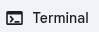

## Instalar Ollama

De seguida vamos instalar o Ollama

In [19]:
!sudo apt update
!sudo apt-get install zstd
!sudo apt install -y pciutils
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,996 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,88

### Comandos a executar no terminal

Depois de abrir o terminal no Colab, é necessário introduzir alguns comandos directamente no terminal para disponibilizar o modelo para utilização. Isto acontece porque, no ambiente do Google Colab, não temos o Ollama pré-instalado nem acesso directo a GPUs potentes, pelo que é preciso preparar o ambiente de execução manualmente.


Após instalar o Ollama, disponibilizamos o servidor do mesmo com

```
ollama serve &
```
Isto fará o ollama correr no background do terminal, permitindo a introdução de novos comandos.

Por fim, precisamos de descarregar os modelos que vamos utilizar com os commandos ollama pull. Vamos usar o gemma3:1b-it-qat (*ollama pull gemma3:1b-it-qat*) assim como usaremos o modelo nomic-embed-text para geração dos embeddings (usado em exercícios mais abaixo) .


**Nota:** O modelo gemma3:1b-it-qat é uma versão quantizada do Gemma-3.
A quantização é uma técnica que reduz o tamanho e os requisitos computacionais do modelo (por exemplo, convertendo pesos de 16/32 bits para 4/8 bits), permitindo executá-lo em hardware mais modesto sem sacrificar demasiado a performance.

```
ollama pull  gemma3:1b-it-qat
```


```
ollama pull  nomic-embed-text
```




Podemos agora verificar se o modelo está disponível para utilização!

In [20]:
!ollama list

NAME                       ID              SIZE      MODIFIED           
nomic-embed-text:latest    0a109f422b47    274 MB    34 seconds ago        
gemma3:1b-it-qat           b491bd3989c6    1.0 GB    About a minute ago    


Se o output da célula anterior foi algo como:



```
NAME                ID              SIZE      MODIFIED       
gemma3:1b-it-qat    b491bd3989c6    1.0 GB    22 seconds ago    
```

Então está tudo pronto!

## Explorar o Gemma3

 Para fazer perguntas ao modelo, vamos usar o LangChain, uma ferramenta que simplifica a interação com modelos de linguagem, permitindo construir aplicações conversacionais, encadear prompts e gerir o contexto das respostas de forma estruturada. (mais detalhes na próxima aula)

Começamos por instalar as bibliotecas necessárias

In [21]:
!pip install langchain langchain-ollama

In [22]:
from langchain_ollama import OllamaLLM

# Carregar o modelo local hospedado pelo Ollama
llm = OllamaLLM(model="gemma3:1b-it-qat")

# Aqui colocamos a prompt
prompt = "The capital of spain is"

# E aqui geramos a resposta ao invocar (invoke) o modelo com a prompt
response = llm.invoke(prompt)


In [23]:
print(response)

The capital of Spain is **Madrid**.



## Alucinações

No entanto, os modelos generativos não são perfeitos e nem sempre conseguem responder corretamente a todas as perguntas. Um dos fenómenos mais comuns é o das chamadas “alucinações”, situações em que o modelo gera informações incorretas, inventadas ou não verificáveis, mas apresentadas de forma convincente e coerente.

Este comportamento decorre do facto de modelos como o Gemma3 não possuirem conhecimento real ou acesso direto a fontes externas de informação, baseando-se apenas nos padrões estatísticos aprendidos durante o treino. Assim, quando não encontra correspondência clara nos seus dados, o modelo tende a preencher lacunas com conteúdo plausível, mas potencialmente errado.

Este problema é particularmente evidente em modelos mais compactos, cuja capacidade de armazenamento de conhecimento é mais limitada, reduzindo a precisão das respostas e aumentando a probabilidade de alucinações factuais ou semânticas.

In [24]:
prompt = "Who is Adamastor?"
response = llm.invoke(prompt)

In [25]:
print(response)

Adamastor is a fascinating and somewhat mysterious figure in the history of New England folklore. Here's a breakdown of who he is and his origins:

**What is Adamastor?**

Adamastor is a legendary, monstrous creature said to inhabit the deep, dark forests of Massachusetts and Rhode Island, particularly in the areas around the Connecticut River and the Pocono Mountains. He's a complex and unsettling being, often described as a colossal, shadowy figure with a terrifying appearance.

**Origins & Legend:**

* **Early Accounts (16th Century):** The earliest written accounts of Adamastor appear in the 16th century. These documents, primarily from the Pilgrim diaries and accounts of various settlers, describe a terrifying, gigantic beast that roamed these areas.
* **The "Lost Pilgrims" Narrative:** A particularly compelling and influential account comes from the *Lost Pilgrims* of the 1690s.  This account, written by William Weaver, details how a group of Pilgrims encountered a massive, spect

**Exercício**: Consegue pensar noutros exemplos onde alucinações possam ocorrer? Relembre que os modelos muitas vezes aprendem com padrões estatisticos.

**Exercício**: Será que estes modelos são bons a matemática no geral? Mais uma vez pense na maneira como os modelos aprendem.

Resposta:

**Exercício**: Verifique agora a sua teoria ao experimentar com alguns problemas de matemática (por exemplo "O João tinha 3 maçãs e cada uma custou 0,30 euros. Quanto gastou o João em maçãs?"). Vá aumentando a dificuldade do problema e veja se consegue que o modelo erre a resposta. Por exemplo:

In [26]:
prompt = "O João tinha 3 maçãs e cada uma custou 0,30 euros. Vendeu uma à Rute por 15 cêntimos e outra ao Gaspar por 40 cêntimos? O João teve lucro?"
response = llm.invoke(prompt)

In [27]:
print(response)

Vamos calcular o lucro do João:

*   **Preço da primeira maçã:** 3 maçãs * 0,30 euros/maçã = 0,90 euros
*   **Preço da segunda maçã:** 15 cêntimos/maçã = 0,15 euros
*   **Lucro total:** 0,90 euros - 0,15 euros = 0,75 euros

**Conclusão:** O João teve lucro de 0,75 euros.


## Exercicios Opcionais: Criar um chatbot!

### Mas então e o chat?

Como aprendemos no módulo teórico, os modelos conversacionais são treinados para gerar sequências mais em conformidade com o diálogo humano através do processo de RLHF. No entanto, os modelos não possuem uma abilidade inerente em manter uma memória da conversa que foi tendo com os utilizadores

In [28]:
prompt = "Bom dia! O meu nome é João! Que lindo dia que está hoje não?"
response = llm.invoke(prompt)
print(response)

Bom dia, João! Que ótimo que você está sorrindo! Sim, o dia está lindo! 😊 

Como posso te ajudar hoje?



In [29]:
prompt = "Qual é o meu nome?"
response = llm.invoke(prompt)
print(response)

Eu não tenho acesso à sua informação pessoal, incluindo seu nome. Eu sou um modelo de linguagem e não tenho memória do passado ou a capacidade de saber algo sobre você.

Se você tiver se perguntado sobre seu nome, talvez esteja pensando em uma pessoa específica? 😊


Vamos agora criar uma versão simples de um chatbot. O objetivo é construir um programa capaz de manter uma breve memória da conversa e interagir continuamente com o utilizador através do modelo Gemma3. Para isso, vamos usar o código fornecido anteriormente, mas com algumas adaptações. Antes de enviar uma nova mensagem (prompt) ao modelo, o programa deve incluir o histórico da conversa anterior. Esse histórico será guardado numa lista, em que cada elemento representa uma interação: as mensagens do utilizador terão o formato user:texto1 e as respostas do modelo o formato chat:texto2.

Se a lista do chat estiver vazia, o programa deve simplesmente enviar a prompt diretamente ao modelo e guardar tanto a mensagem enviada como a resposta recebida na lista. Caso a lista já contenha interações anteriores, o programa deve recuperar as últimas n entradas e juntá-las à nova prompt, acrescentando uma frase introdutória, como por exemplo “Isto é o histórico da conversa até agora”. Todo este processo deve ser colocado dentro de um ciclo infinito (while True:), garantindo que a interação entre o utilizador e o chatbot continua até que o programa seja interrompido manualmente.p

###**Pergunta**:
Antes de continuar os próximos exercícios, tem alguma ideia de como poderá o modelo reter memória da conversa? **Pista:** a capacidade da memória está dependente do número de tokens máximo que o modelo consegue interpretar

**RESPOSTA AQUI**

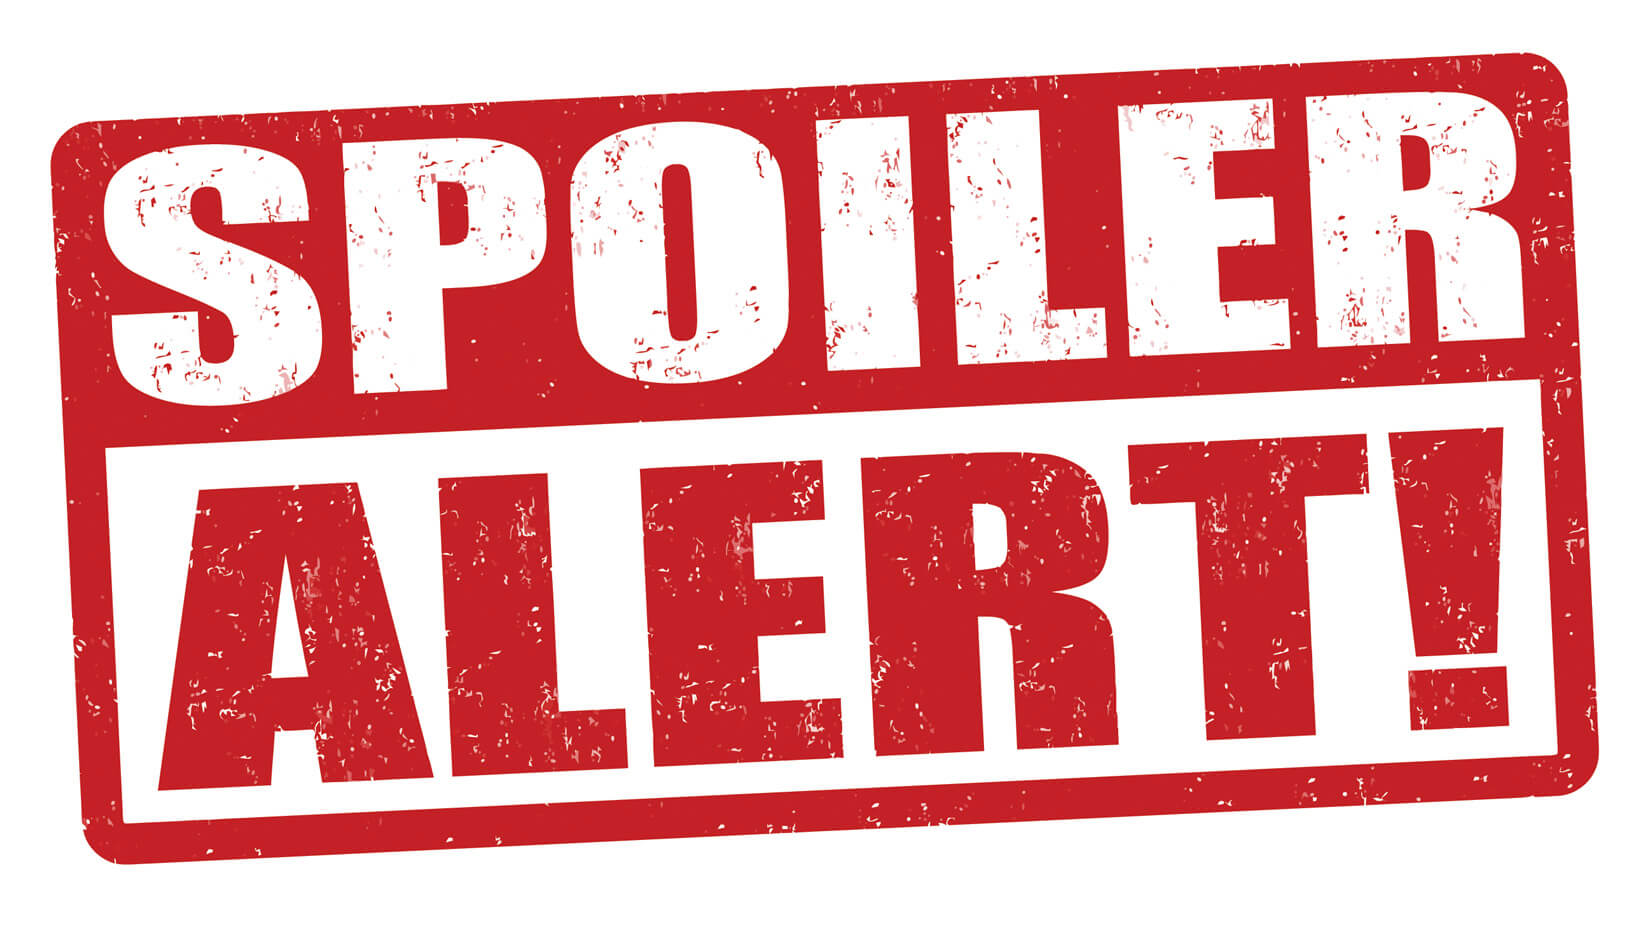

Na verdade o que permite os modelos perservarem memória da conversa em discurso é a inserção do histórico do chat (ou pelo menos as interações mais recentes) automaticamente dentro da prompt após o pedido do utilizador. A figura abaixo apresenta um diagrama desse processo.

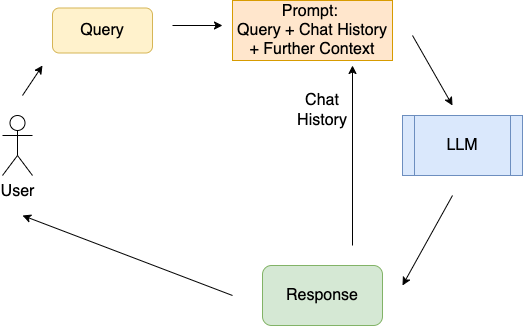

###**Exercício (versão passo-a-passo):**
Na verdade, a biblioteca LangChain já nos permite criar o nosso próprio chatbot com memória de uma forma muito mais simples e organizada. Em vez de gerirmos manualmente o histórico da conversa, o LangChain disponibiliza ferramentas que tratam dessa lógica automaticamente. Assim, podemos concentrar-nos em definir o comportamento do chatbot e em estabelecer a ligação ao Ollama, que contêm o modelo responsável por gerar as respostas. O objetivo deste exercício é compreender como o LangChain facilita a criação de um chatbot com memória e experimentar uma implementação básica dessa funcionalidade.

Vamos fazer este exercício passo-a-passo

In [30]:
!pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory

 Aqui precisamos de carregar o modelo do Ollama. Já foi feito em cima e portanto não é nada de novo.


In [ ]:
#Criar o modelo Gemma3
llm = ChatOllama(model="gemma3:1b-it-qat")

A seguir adicionamos um template de prompt, que define a estrutura das mensagens enviadas ao modelo (vamos falar deste assunto na próxima aula). Neste indicamos primeiro uma mensagem de sistema, que orienta o comportamento do assistente (You are Gemma, a friendly and concise AI assistant.). A seguir temos um espaço reservado para o histórico da conversa, que permitirá ao modelo lembrar-se do que já foi dito. Por fim, a mensagem do utilizador, representada pela variável {input}, que será substituída pelo texto introduzido em cada interação.

In [ ]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "Tu és o Gemma, uma IA muito amigável."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

De seguida, criamos a variável history, que serve para guardar todas as mensagens trocadas durante a conversa. Ao usar a função InMemoryChatMessageHistory(), o histórico é mantido apenas na memória enquanto o programa está a correr.

In [ ]:
history = InMemoryChatMessageHistory()

Aqui combinamos o template de prompt com o modelo de linguagem (llm) através do operador |, que em LangChain significa “encadear” etapas. Assim, o prompt prepara as mensagens e o llm gera a resposta, formando juntos uma cadeia (chain) que transforma a entrada do utilizador numa resposta produzida pelo modelo.

In [ ]:
chain = prompt | llm

Nesta linha criamos o objeto chatbot, que combina a cadeia *chain* com o histórico de conversas. O *RunnableWithMessageHistory* garante que, a cada nova interação, o histórico guardado em *history* seja automaticamente incluído no contexto enviado ao modelo. A função lambda _: history indica que será sempre usado o mesmo histórico (pois só há um utilizador), enquanto os parâmetros input_messages_key e history_messages_key definem os nomes das variáveis que o sistema deve usar para identificar a nova mensagem e o histórico da conversa.

In [ ]:
chatbot = RunnableWithMessageHistory(
    chain,
    lambda _: history,               # we don’t need multiple sessions
    input_messages_key="input",
    history_messages_key="history",
)


Neste bloco definimos um ID de sessão (session_id = "single_user") que o LangChain exige para gerir o histórico de cada conversa. Isto permite, em aplicações maiores, que vários utilizadores conversem simultaneamente sem misturar contextos. Em seguida, criamos a configuração config que associa esse ID à chamada do modelo.

O ciclo while True inicia o chatbot interativo: a cada mensagem introduzida pelo utilizador, o texto é enviado ao modelo através de chatbot.invoke(...), que devolve a resposta já considerando todo o histórico guardado.

In [ ]:
session_id = "single_user" # O langchain obriga-nos a definir um id de sessão (isto permite ter vários utilizadores a aceder ao mesmo tempo sem interferir com as conversas um dos outros)
config={"configurable": {"session_id": session_id}} #configuramos esse id para invocar a LLM

#Iniciar o chatbot!
print("🤖 Nova (Gemma3 chatbot) — type 'exit' to quit")
while True:
    user_input = input("Tu: ")
    if user_input.lower() in ["exit", "quit"]:
        print("Gemma: Adeus 👋")
        break

    response = chatbot.invoke({"input": user_input},config=config)
    print("Gemma:", response.content)

#RAG

## O que vamos usar


Vamos agora criar uma aplicação RAG (Retrieval-Augmented Generation). Este tipo de aplicação combina a recuperação de informação com a geração de texto, permitindo que um modelo de linguagem (como o Gemma3) produza respostas mais precisas e fundamentadas em dados externos. Para isso, vamos construir três componentes principais.

- O primeiro é a base de dados vetorial (vector database), onde iremos armazenar a informação em formato vetorial. Este formato permite que os dados sejam procurados de forma semântica, isto é, com base no significado do texto e não apenas em palavras-chave.

- O segundo componente é o mecanismo de recuperação (retriever), responsável por procurar dentro da base vetorial os vetores mais semelhantes à consulta feita pelo utilizador. Estes vetores correspondem aos documentos ou trechos de texto mais relevantes para a pergunta.

- Por fim, o terceiro componente é o modelo generativo. Este modelo utiliza a informação recuperada pelo retriever para gerar respostas completas, contextualizadas e suportadas por dados reais, em vez de depender apenas do conhecimento interno do modelo.

Neste exemplo, vamos utilizar dados da Internet para simplificar o processo e focar na parte técnica da implementação. No entanto, poderíamos utilizar qualquer outro tipo de documento, como textos biográficos, regulamentos internos, políticas empresariais ou manuais técnicos, dependendo do objetivo da aplicação.

Vamos usar o LangChain, uma vez que esta biblioteca oferece uma integração com pipelines de RAG e fornece ferramentas prontas para lidar com cada etapa do processo (desde a recuperação de informação até à geração de respostas.

Vamos também utilizar o [Chroma](https://python.langchain.com/docs/integrations/vectorstores/chroma/) para armazenar e pesquisar os nossos vetores. O Chroma  é uma base de dados vetorial simples e eficiente que nos permitirá guardar os embeddings e recuperar contexto de forma rápida e semântica.

Por fim, vamos usar o OllamaEmbeddings para converter o texto em vetores numéricos (embeddings). Estes vetores representam o significado das frases e serão a base para que o nosso sistema RAG consiga encontrar e utilizar a informação mais relevante.

Como já foi mencionado, para efeitos de demonstração, vamos utilizar dados provenientes da Internet. Para isso, iremos recorrer ao módulo WebBaseLoader do LangChain, que nos permite extrair e converter o conteúdo estruturado de páginas HTML em texto.


Finalmente, iremos utilizar o Gradio, uma biblioteca em Python que permite criar interfaces gráficas interativas de forma rápida e intuitiva, sem necessidade de conhecimentos avançados de front-end ou desenvolvimento web.

No nosso caso, vamos usar o Gradio para construir uma interface de chatbot, que permitirá interagir com o nosso sistema RAG de forma visual e amigável.

In [ ]:
#já deverá estar de cima mas podemos sempre correr outra vez
!pip install langchain
#!pip install langchain-core
# as outras parte necessárias do langchain
!pip install langchain-community
!pip install langchain-text-splitters

!pip install chromadb
!pip install gradio

In [ ]:
!pip install ollama

A seguir importamos as bibliotecas necessárias

In [ ]:
import gradio as gr                       # Para a interface web
import ollama
from langchain_text_splitters import RecursiveCharacterTextSplitter # Divide textos longos em blocos menores (útil para o armazenamento de dados)
from langchain_community.document_loaders import WebBaseLoader      # Carrega conteúdo diretamente de páginas web
from langchain_community.vectorstores import Chroma                 # Base de dados vetorial para armazenar embeddings
from langchain_community.embeddings import OllamaEmbeddings         # Gera embeddings a partir de texto usando o Ollama

Próximo passo é definir as fontes que queremos usar (isto é, os websites onde vamos procurar informação). O WebBaseLoader faz o download do HTML e converte-o num formato estruturado que o LangChain pode utilizar como documento. Este será o ponto de partida para gerar os embeddings e construir a nossa base de dados vetorial.

In [ ]:

url = 'https://en.wikipedia.org/wiki/Os_Lus%C3%ADadas' #mais completo
#url ='https://www.culturagenial.com/os-lusiadas-de-camoes/' # mais simples
loader = WebBaseLoader(url)
docs = loader.load()

Depois de carregar o conteúdo da página, é importante dividir o texto em partes menores para facilitar o processamento e a criação dos embeddings.

Utilizamos o RecursiveCharacterTextSplitter do LangChain, que separa o texto em blocos de até 1000 caracteres, com uma sobreposição de 200 caracteres entre eles.
Esta sobreposição ajuda o modelo a preservar o contexto entre os blocos, evitando perda de informação importante nas transições do texto.

In [ ]:

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)


Usamos o OllamaEmbeddings para converter os blocos de texto em vetores numéricos (embeddings). De seguida, o Chroma armazena esses vetores numa base de dados vetorial, permitindo recuperar rapidamente o conteúdo mais relevante durante as consultas.


In [ ]:
# Cria os embeddings usando o Ollama embeddings (com o modelo nomic-embed-text) e guarda numa vector store
# Pode demorar um pouco dependendo do tamanho do ficheiro (neste ambiente pode demorar alguns minutos (mais de 5)
#por causa do tamanho da página)
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)

Nesta etapa, definimos a função ollama_llm, responsável por enviar uma pergunta e o respetivo contexto para o modelo de linguagem Gemma3, executado localmente através do Ollama.

A função começa por criar um prompt template que vai combinar a pergunta do utilizador com o contexto recuperado da base vetorial. Em seguida, faz a chamada ao modelo utilizando ollama.chat(), que retorna a resposta gerada.

In [ ]:
def ollama_llm(question, context):
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response = ollama.chat(model="gemma3:1b-it-qat", messages=[{'role': 'user', 'content': formatted_prompt}])
    return response['message']['content']

Aqui criamos o retriever a partir da base de dados vetorial Chroma, responsável por encontrar os textos mais relevantes em relação à pergunta do utilizador. Quando uma consulta é feita, o retriever converte a pergunta em embeddings e compara-os com os vetores armazenados, medindo a similaridade semântica para identificar os blocos de texto mais próximos no significado.

O método as_retriever() pode receber argumentos como search_type="similarity"  ou search_type="mmr" e search_kwargs={"fetch_k": 3} para definir quantos resultados o retriever deve retornar (por defeito 20). Estes parâmetros permitem equilibrar precisão e diversidade na recuperação de contexto antes do envio para o modelo LLM. Mais informações na [documentação](https://python.langchain.com/api_reference/core/vectorstores/langchain_core.vectorstores.base.VectorStore.html#langchain_core.vectorstores.base.VectorStore.as_retriever)

In [ ]:
retriever = vectorstore.as_retriever()

A função rag_chain representa o fluxo completo do sistema RAG. Quando o utilizador faz uma pergunta, esta é primeiro enviada ao retriever, que procura na base vetorial os documentos mais relevantes e os devolve sob a forma de uma lista de trechos de texto. Em seguida, esses textos são concatenados num único contexto formatado, utilizando "\n\n".join(...) para manter a legibilidade.

Esse contexto é então passado, juntamente com a pergunta original, para a função ollama_llm, que chama o modelo de linguagem para gerar uma resposta final.

In [ ]:
def rag_chain(question):
    retrieved_docs = retriever.invoke(question)
    formatted_context = "\n\n".join(doc.page_content for doc in retrieved_docs)
    answer=ollama_llm(question, formatted_context)
    return answer

In [ ]:
rag_chain("Who is Adamastor?")

##Opcional: Criação de Interface

Finalmente criamos a  interface da nossa aplicação!

Primeiro, definimos uma função simples (get_important_facts), que serve como ponto de ligação entre o Gradio e o nosso sistema RAG. Sempre que o utilizador introduz uma pergunta, essa função chama a rag_chain, executando todo o fluxo de prcura de infomração na base de dados e geração de resposta usando o Gemma3.

Em seguida, criamos a interface com gr.Interface(), especificando a função que será executada (fn), o campo de entrada (Textbox), e o tipo de saída (text). Também definimos um título e uma descrição para tornar a aplicação mais intuitiva. Por fim, iface.launch() inicia a aplicação web, permitindo interagir diretamente com o chatbot de forma simples e visual.

In [ ]:
# Define the Gradio interface
def get_important_facts(question):
    return rag_chain(question)

# Create a Gradio app interface
iface = gr.Interface(
  fn=get_important_facts,
  inputs=gr.Textbox(lines=2, placeholder="Enter your question here..."),
  outputs=gr.Textbox(lines=4),
  title="RAG com Gemma3",
  description="Faça perguntas do conteudo armazenado!",
)

# Launch the Gradio app
iface.launch()
